#### Aufgabe: Customer Churn

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
Churn
No     5174
Yes    1869
Name: count, dtype: int64


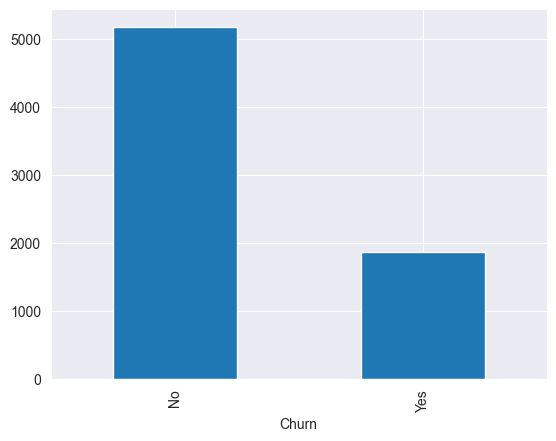

   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  Churn  gender_Male  \
0              0       1           29.85         29.85      0        False   
1              0      34           56.95       1889.50      0         True   
2              0       2           53.85        108.15      1         True   
3              0      45           42.30       1840.75      0         True   
4              0       2           70.70        151.65      1        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True           False             False   
1        False           False              True   
2        False           False              True   
3        False           False             False   
4        False           False              True   

   MultipleLines_No phone service  ...  StreamingTV_No internet service  \
0                            True  ...                            False   
1                           False  ...                            Fa

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Laden
df = pd.read_csv("Telco-Customer-Churn.csv")

# 2. TotalCharges bereinigen
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

# 3. Fehlende Werte prüfen
print(df.isna().sum())

# 4. Zielvariable analysieren
print(df["Churn"].value_counts())
df["Churn"].value_counts().plot(kind="bar")
plt.show()

# 5. Unnötige Spalte löschen
df = df.drop(columns=["customerID"])

# 6. Zielvariable encoden
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# 7. Kategoriale Variablen encoden
categorical_cols = df.select_dtypes(include=["object"]).columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print(df.head())
print(df.shape)


Train Accuracy: 0.7894523326572008
Test Accuracy: 0.7770941788925698


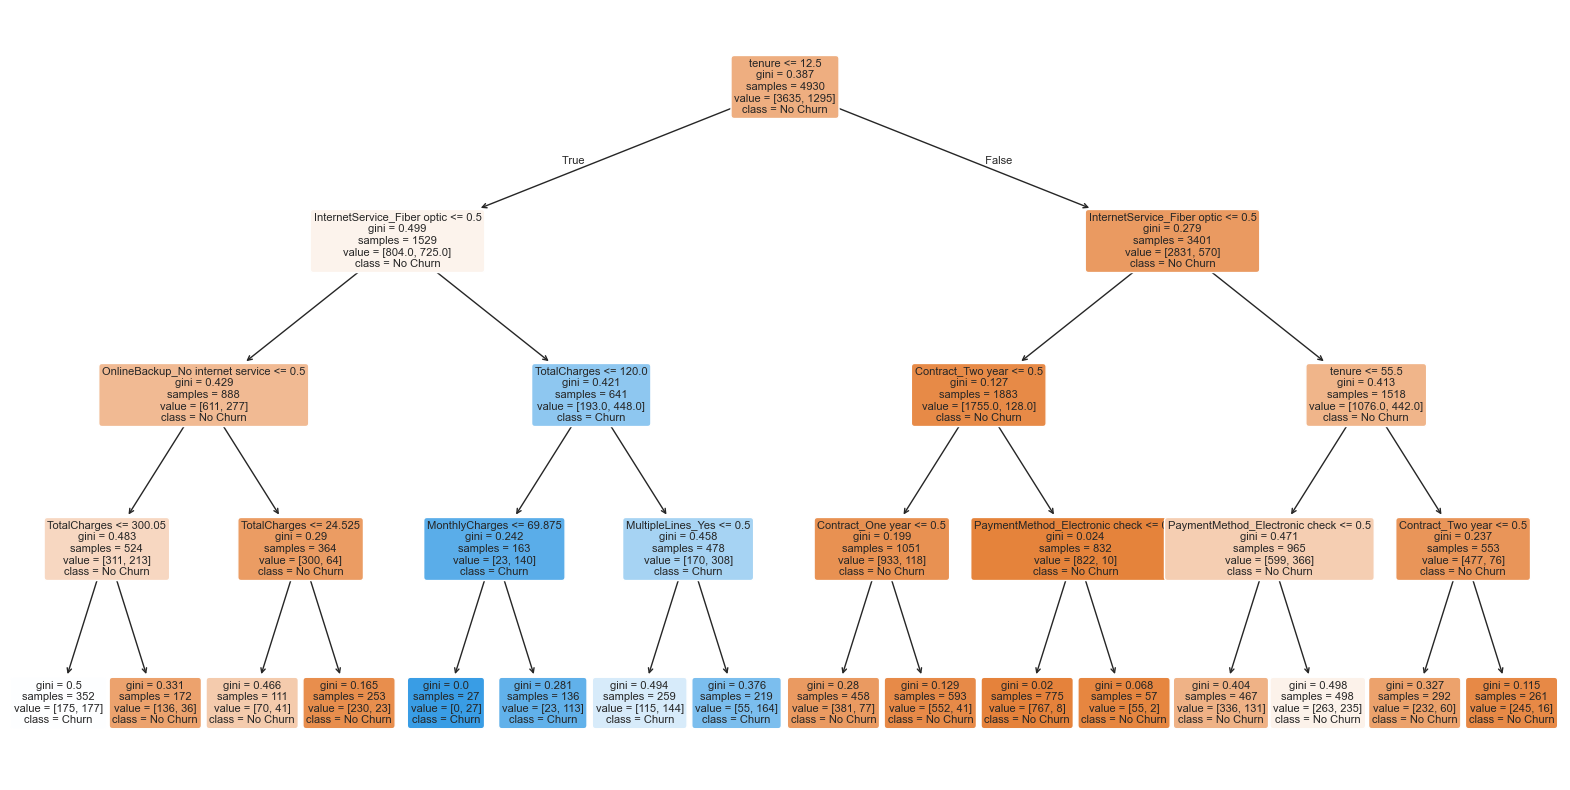

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# 1. Features & Zielvariable
X = df.drop(columns=["Churn"])
y = df["Churn"]

# 2. Train/Test-Split (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

# 3. Entscheidungsbaum-Modell (Gini oder Entropy)
model = DecisionTreeClassifier(
    criterion="gini",     # oder criterion="entropy"
    max_depth=4,           # sinnvolle Begrenzung für bessere Darstellung
    random_state=42
)

model.fit(X_train, y_train)

# 4. Modellgüte ausgeben
print("Train Accuracy:", model.score(X_train, y_train))
print("Test Accuracy:", model.score(X_test, y_test))

# 5. Baum visualisieren
plt.figure(figsize=(20, 10))
plot_tree(model, feature_names=X.columns, class_names=["No Churn", "Churn"],
          filled=True, rounded=True, fontsize=8)
plt.show()


Accuracy : 0.7770941788925698
Precision: 0.6189376443418014
Recall   : 0.46689895470383275
F1-Score : 0.5322740814299901

Classification Report:

              precision    recall  f1-score   support

    No Churn       0.82      0.89      0.85      1539
       Churn       0.62      0.47      0.53       574

    accuracy                           0.78      2113
   macro avg       0.72      0.68      0.69      2113
weighted avg       0.76      0.78      0.77      2113

Confusion Matrix (Zahlen):
 [[1374  165]
 [ 306  268]]


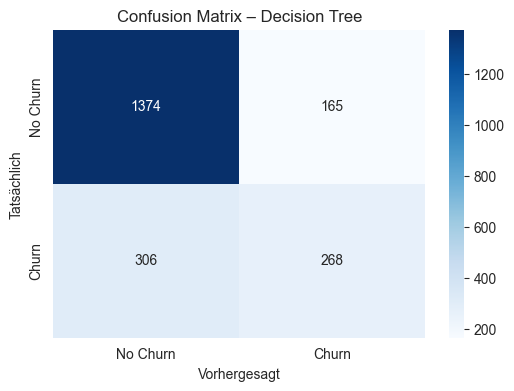

In [36]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

# Vorhersagen
y_pred = model.predict(X_test)

# Kennzahlen
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-Score :", f1_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix (Zahlen):\n", cm)

# Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"])
plt.xlabel("Vorhergesagt")
plt.ylabel("Tatsächlich")
plt.title("Confusion Matrix – Decision Tree")
plt.show()


In [38]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Hyperparameter-Raum definieren
param_grid = {
    "max_depth": [3, 5, 7, 9, None],
    "min_samples_split": [2, 10, 20],
    "min_samples_leaf": [1, 5, 10]
}

# 2. Grid Search einrichten
base_tree = DecisionTreeClassifier(
    criterion="gini",   # oder "entropy"
    random_state=42
)

grid_search = GridSearchCV(
    estimator=base_tree,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=1
)

# 3. Training mit Cross-Validation
grid_search.fit(X_train, y_train)

print("Beste Hyperparameter:", grid_search.best_params_)
print("Beste CV-Accuracy   :", grid_search.best_score_)

# 4. Bestes Modell auf Testdaten bewerten
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

print("\nTest-Accuracy (optimierter Baum):", accuracy_score(y_test, y_pred_best))
print("\nClassification Report (optimierter Baum):")
print(classification_report(y_test, y_pred_best, target_names=["No Churn", "Churn"]))


Beste Hyperparameter: {'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 2}
Beste CV-Accuracy   : 0.7886409736308316

Test-Accuracy (optimierter Baum): 0.7917652626597255

Classification Report (optimierter Baum):
              precision    recall  f1-score   support

    No Churn       0.85      0.86      0.86      1539
       Churn       0.62      0.61      0.61       574

    accuracy                           0.79      2113
   macro avg       0.74      0.73      0.74      2113
weighted avg       0.79      0.79      0.79      2113



Wichtigste Merkmale (sortiert):
tenure                                 0.404240
InternetService_Fiber optic            0.327997
TotalCharges                           0.079461
OnlineBackup_No internet service       0.038400
MonthlyCharges                         0.034728
PaymentMethod_Electronic check         0.029767
Contract_Two year                      0.026551
Contract_One year                      0.024704
MultipleLines_Yes                      0.014832
MultipleLines_No phone service         0.008502
StreamingMovies_Yes                    0.005750
OnlineBackup_Yes                       0.005068
TechSupport_Yes                        0.000000
StreamingMovies_No internet service    0.000000
PaperlessBilling_Yes                   0.000000
dtype: float64


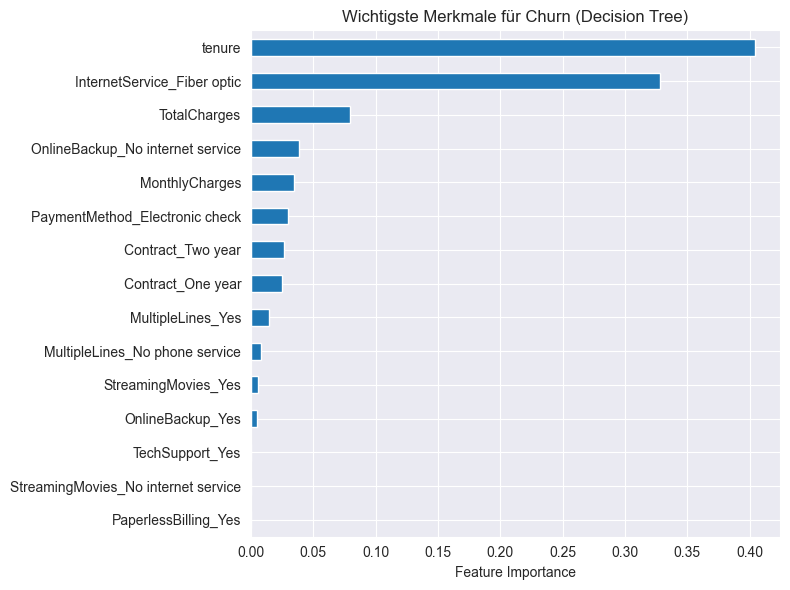

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Falls du den "normalen" Baum verwenden willst, nimm model statt best_model
tree = best_model   # oder: tree = model

# 1. Feature Importances auslesen
importances = pd.Series(tree.feature_importances_, index=X.columns)

# 2. Nach Wichtigkeit sortieren
importances_sorted = importances.sort_values(ascending=False)

# 3. Wichtigste Features ausgeben (z.B. Top 15)
print("Wichtigste Merkmale (sortiert):")
print(importances_sorted.head(15))

# 4. Visualisierung als horizontales Balkendiagramm
plt.figure(figsize=(8, 6))
importances_sorted.head(15).plot(kind="barh")
plt.gca().invert_yaxis()  # wichtigstes Feature oben
plt.xlabel("Feature Importance")
plt.title("Wichtigste Merkmale für Churn (Decision Tree)")
plt.tight_layout()
plt.show()


CV-Scores pro Fold: [0.79347055 0.78921221 0.77714691 0.79119318 0.78835227]
Durchschnittliche Accuracy: 0.7878750241951094
Standardabweichung: 0.0056467378290236845


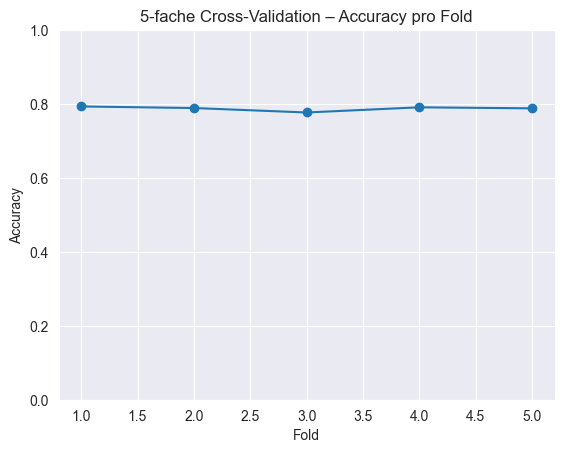

In [40]:
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

# X und y: Features und Zielvariable
# X = df.drop(columns=["Churn"])
# y = df["Churn"]

# 5-fache Cross-Validation mit dem Entscheidungsbaum
cv_scores = cross_val_score(model, X, y, cv=5, scoring="accuracy")

print("CV-Scores pro Fold:", cv_scores)
print("Durchschnittliche Accuracy:", cv_scores.mean())
print("Standardabweichung:", cv_scores.std())

# Optional: grafische Darstellung
plt.plot(range(1, len(cv_scores) + 1), cv_scores, marker="o")
plt.title("5-fache Cross-Validation – Accuracy pro Fold")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(True)
plt.show()


#### Aufgabe: Random Forest

Shape: (569, 30)
Missing values: 0

=== RandomForest ===
Accuracy: 0.935672514619883
Classification Report:
               precision    recall  f1-score   support

   malignant       0.92      0.91      0.91        64
      benign       0.94      0.95      0.95       107

    accuracy                           0.94       171
   macro avg       0.93      0.93      0.93       171
weighted avg       0.94      0.94      0.94       171


=== XGBoost ===
Accuracy: 0.9649122807017544
Classification Report:
               precision    recall  f1-score   support

   malignant       0.98      0.92      0.95        64
      benign       0.95      0.99      0.97       107

    accuracy                           0.96       171
   macro avg       0.97      0.96      0.96       171
weighted avg       0.97      0.96      0.96       171


=== LightGBM ===
Accuracy: 0.9649122807017544
Classification Report:
               precision    recall  f1-score   support

   malignant       0.98      0.92      0.

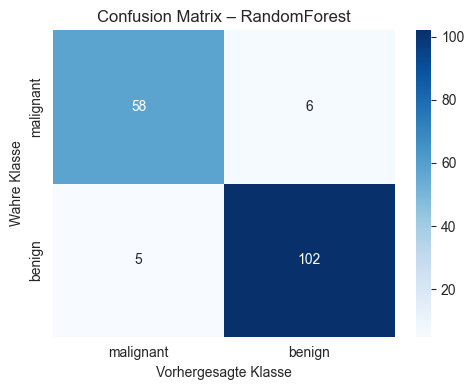

In [51]:
# ===========================================
# Imports
# ===========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# ===========================================
# 1. Daten laden
# ===========================================
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Shape:", X.shape)
print("Missing values:", X.isna().sum().sum())

# ===========================================
# 2. Train/Test-Split (mit DataFrames)
# ===========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# ===========================================
# 3. StandardScaler, aber DataFrame bleibt erhalten
# ===========================================
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

# ===========================================
# 4. Modelle definieren
# ===========================================
models = {
    "RandomForest": RandomForestClassifier(random_state=42),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),

    "LightGBM": LGBMClassifier(
        random_state=42,
        verbose=-1
    )
}

results = {}

# ===========================================
# 5. Modelle trainieren & bewerten (mit DataFrame Input)
# ===========================================
for name, model in models.items():
    model.fit(X_train_scaled, y_train)      # Train mit DF + Feature-Namen
    y_pred = model.predict(X_test_scaled)   # Predict mit DF + Feature-Namen

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"\n=== {name} ===")
    print("Accuracy:", acc)
    print("Classification Report:\n",
          classification_report(y_test, y_pred, target_names=data.target_names))

# ===========================================
# 6. Modellvergleich
# ===========================================
print("\n=== Modellvergleich (Accuracy) ===")
for name, acc in results.items():
    print(f"{name}: {acc:.4f}")

# ===========================================
# 7. Confusion Matrix für RandomForest
# ===========================================
rf = models["RandomForest"]
y_pred_rf = rf.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=data.target_names,
    yticklabels=data.target_names
)
plt.xlabel("Vorhergesagte Klasse")
plt.ylabel("Wahre Klasse")
plt.title("Confusion Matrix – RandomForest")
plt.tight_layout()
plt.show()


#### Aufgabe: Random Forest mit Feature Engineering